# Samll test of processing PS images in Python
# created on 8/14/2025

## refering materials
- https://autogis-site.readthedocs.io/en/2021/notebooks/L2/00-data-io.html

In [2]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import fiona
import os
import rasterio
from rasterio.plot import show
from rasterio.mask import mask

import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [3]:
# read all materials
ra_dir = 'W:/GIS_Data/SatelliteImagery/HighResolution/Morocco/AI_Baten_2025_July_psscene_analytic_8b_sr_udm2/PSScene/'

# csv:trainning table, extracted values from raster
df = pd.read_csv(ra_dir + 'Trophic survey_vegetation taxa cover_2016-2023_al_baten_rsvalues.csv')
# raster dir and file path
fp_ref = ra_dir + '20250711_PS_8b_mosaic_ref.tif'
fp_si = ra_dir + '20250711_PS_8b_mosaic_si.tif'
fp_mo = ra_dir + '20250711_PS_8b_mosaic.tif'
outfp = ra_dir + '20250711_PS_8b_pred.tif'
outfp2 = ra_dir + '20250711_PS_8b_pred_masked_Fveg.tif'
ra_fp = ra_dir + '20250711_PS_bands_si.tif'

# shp file path
shp_fp = 'C:/Users/PangY/OneDrive - Smithsonian Institution/Bustard/01_Data/Reneco/GIS Data/Extract data Yuwen/Shapefiles/Al_Baten_study_area.shp'
AI_shp = gpd.read_file(shp_fp)

## Extract raster values to points
- Raster: **20250711_PS_bands_si.tif**
- Points/stations: **Trophic survey_vegetation taxa cover_2016-2023_al_baten_rsvalues.csv**
- Purpose extrct raster bands'values to points

In [6]:
import rasterio
import geopandas as gpd

# Example for loading from a shapefile
shp_dir = 'C:/Users/PangY/OneDrive - Smithsonian Institution/Bustard/01_Data/Reneco/Vegetation Cover and Food Availability Studies/'
shp_gdf = gpd.read_file(shp_dir + 'Trophic survey_vegetation taxa cover_2016-2023_al_baten.shp')

ra_dir = 'W:/GIS_Data/SatelliteImagery/HighResolution/Morocco/AI_Baten_2025_July_psscene_analytic_8b_sr_udm2/PSScene/'
ra_fp = ra_dir + '20250711_PS_bands_si.tif'

In [9]:
shp_gdf.crs #4326
shp_gdf = shp_gdf.to_crs("EPSG:32630")
shp_gdf.crs

<Projected CRS: EPSG:32630>
Name: WGS 84 / UTM zone 30N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 6°W and 0°W, northern hemisphere between equator and 84°N, onshore and offshore. Algeria. Burkina Faso. Côte' Ivoire (Ivory Coast). Faroe Islands - offshore. France. Ghana. Gibraltar. Ireland - offshore Irish Sea. Mali. Mauritania. Morocco. Spain. United Kingdom (UK).
- bounds: (-6.0, 0.0, 0.0, 84.0)
Coordinate Operation:
- name: UTM zone 30N
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [13]:
# Define output path
shp_out1 = shp_dir + 'Trophic survey_vegetation taxa cover_2016-2023_al_baten_prj.shp'
# point = shp_gdf.to_file(shp_out1, driver='Shapefile')
point = gpd.read_file(shp_out1)
point.shape #(708, 20)

In [8]:
src = rasterio.open(ra_fp)
src.meta #32630

{'driver': 'GTiff',
 'dtype': 'float32',
 'nodata': 0.0,
 'width': 12850,
 'height': 11619,
 'count': 27,
 'crs': CRS.from_epsg(32630),
 'transform': Affine(3.0, 0.0, 393249.0,
        0.0, -3.0, 3691608.0)}

In [16]:
import geopandas as gpd
import rasterio
from rasterio.transform import Affine
import pandas as pd

# -------------------------------
# 1. File paths
# -------------------------------
ra_dir = 'W:/GIS_Data/SatelliteImagery/HighResolution/Morocco/AI_Baten_2025_July_psscene_analytic_8b_sr_udm2/PSScene/'
raster_path = ra_dir + '20250711_PS_bands_si.tif'
shp_dir = 'C:/Users/PangY/OneDrive - Smithsonian Institution/Bustard/01_Data/Reneco/Vegetation Cover and Food Availability Studies/'
points_path = shp_dir + 'Trophic survey_vegetation taxa cover_2016-2023_al_baten_prj.shp'

# -------------------------------
# 2. Load point shapefile
# -------------------------------
points = gpd.read_file(points_path)
print("Points loaded:", len(points))

# -------------------------------
# 3. Open raster and check CRS
# -------------------------------
try:
    with rasterio.open(raster_path) as src:
        raster_crs = src.crs
        raster_transform = src.transform
        band_count = src.count

        print(f"Raster opened. CRS: {raster_crs}, Bands: {band_count}")

        # Ensure CRS alignment
        if points.crs != raster_crs:
            print(f"CRS mismatch detected. Reprojecting points from {points.crs} to {raster_crs}...")
            points = points.to_crs(raster_crs)
            print("Points reprojected.")

        # -------------------------------
        # 4. Extract values for each band
        # -------------------------------
        coords = [(x,y) for x,y in zip(points.geometry.x, points.geometry.y)]
        print("Extracting values for all bands...")

        # Create dictionary to hold extracted band values
        band_data = {f'band_{i+1}': [] for i in range(band_count)}

        for i in range(1, band_count+1):
            values = [val[0] for val in src.sample(coords, indexes=i)]
            band_data[f'band_{i}'] = values
            print(f"Band {i} extraction complete.")

        # -------------------------------
        # 5. Add extracted values to GeoDataFrame
        # -------------------------------
        for band_name, values in band_data.items():
            points[band_name] = values

except rasterio.errors.RasterioIOError as e:
    print(f"Error opening raster file: {e}")
except Exception as e:
    print(f"Unexpected error: {e}")

# -------------------------------
# 6. Save results
# -------------------------------
output_path = "Trophic survey_vegetation taxa cover_2016-2023_al_baten_ravalues.shp"
points.to_file(output_path)
print(f"Saved updated shapefile with extracted raster values → {output_path}")

# Optional: also save as CSV (attributes only, no geometry)
points.drop(columns="geometry").to_csv("Trophic survey_vegetation taxa cover_2016-2023_al_baten_raster_values.csv", index=False)
print("CSV also saved.")

Points loaded: 708
Raster opened. CRS: EPSG:32630, Bands: 27
Extracting values for all bands...
Band 1 extraction complete.
Band 2 extraction complete.
Band 3 extraction complete.
Band 4 extraction complete.
Band 5 extraction complete.
Band 6 extraction complete.
Band 7 extraction complete.
Band 8 extraction complete.
Band 9 extraction complete.
Band 10 extraction complete.
Band 11 extraction complete.
Band 12 extraction complete.
Band 13 extraction complete.
Band 14 extraction complete.
Band 15 extraction complete.
Band 16 extraction complete.
Band 17 extraction complete.
Band 18 extraction complete.
Band 19 extraction complete.
Band 20 extraction complete.
Band 21 extraction complete.
Band 22 extraction complete.
Band 23 extraction complete.
Band 24 extraction complete.
Band 25 extraction complete.
Band 26 extraction complete.
Band 27 extraction complete.
Saved updated shapefile with extracted raster values → Trophic survey_vegetation taxa cover_2016-2023_al_baten_ravalues.shp
CSV al

## Training table

In [ ]:
# review the data
print(df.head())

In [11]:
print(df.shape)
print(df.columns)
print(df.columns[25:33])
print(df.columns[34:53])

(708, 53)
Index(['name_en', 'status', 'country', 'working_ar', 'working_re', 'owners',
       'Shape_Leng', 'Shape_Area', 'FID_Trophi', 'Station', 'Year', 'Season',
       'Alive', 'Dead', 'Ground', 'Unknown', 'Sum_not_un', 'GridSize',
       'Assessor', 'F__alive', 'F_dead', 'F_ground', 'Lat', 'Lon', 'ID',
       'costalb', 'blue', 'green1', 'green', 'yellow', 'red', 'red edge',
       'nir', 'ID.1', 'CTVI', 'DVI', 'EVI', 'EVI2', 'GEMI', 'GNDVI', 'KNDVI',
       'MCARI', 'MSAVI', 'MSAVI2', 'NDVI', 'NDWI', 'NRVI', 'RVI', 'SAVI', 'SR',
       'TTVI', 'TVI', 'WDVI'],
      dtype='object')
Index(['costalb', 'blue', 'green1', 'green', 'yellow', 'red', 'red edge',
       'nir'],
      dtype='object')
Index(['CTVI', 'DVI', 'EVI', 'EVI2', 'GEMI', 'GNDVI', 'KNDVI', 'MCARI',
       'MSAVI', 'MSAVI2', 'NDVI', 'NDWI', 'NRVI', 'RVI', 'SAVI', 'SR', 'TTVI',
       'TVI', 'WDVI'],
      dtype='object')


In [33]:
df['Season'] # only for Summer

0      Spring
1      Summer
2        Fall
3      Winter
4      Spring
        ...  
703    Winter
704    Spring
705    Summer
706      Fall
707    Winter
Name: Season, Length: 708, dtype: object

In [50]:
# creat the train dataset
# rules: seasons[11] == summer, limited to columns
df1 = df[df['Season'] == 'Summer']
df2 = df1.iloc[:, 25:53]
print(df2.columns)
df2 = df2.drop('ID.1',axis=1)

Index(['costalb', 'blue', 'green1', 'green', 'yellow', 'red', 'red edge',
       'nir', 'ID.1', 'CTVI', 'DVI', 'EVI', 'EVI2', 'GEMI', 'GNDVI', 'KNDVI',
       'MCARI', 'MSAVI', 'MSAVI2', 'NDVI', 'NDWI', 'NRVI', 'RVI', 'SAVI', 'SR',
       'TTVI', 'TVI', 'WDVI'],
      dtype='object')


In [55]:
print(df2.columns)

Index(['costalb', 'blue', 'green1', 'green', 'yellow', 'red', 'red edge',
       'nir', 'CTVI', 'DVI', 'EVI', 'EVI2', 'GEMI', 'GNDVI', 'KNDVI', 'MCARI',
       'MSAVI', 'MSAVI2', 'NDVI', 'NDWI', 'NRVI', 'RVI', 'SAVI', 'SR', 'TTVI',
       'TVI', 'WDVI'],
      dtype='object')


In [59]:
X = df2
y = df1.iloc[:, 21] #F_ground
# print(X)

In [60]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

In [62]:
rf = RandomForestRegressor(n_estimators = 500, random_state = 0)
rf.fit(X, y) 

0.887

In [63]:
round(rf.score(X_train, y_train),3) #0.887

0.887

## RF Modelling

In [64]:
ra = rasterio.open(fp_ref)

In [65]:
ra.meta

{'driver': 'GTiff',
 'dtype': 'float32',
 'nodata': nan,
 'width': 12850,
 'height': 11619,
 'count': 8,
 'crs': CRS.from_epsg(32630),
 'transform': Affine(3.0, 0.0, 393249.0,
        0.0, -3.0, 3691608.0)}

In [66]:
ra_df = ra.read()
ra_df.shape #(8, 11619, 12850)

(8, 11619, 12850)

In [ ]:
ra_df.head()

In [68]:
ra_si = rasterio.open(fp_si)
ra_si.meta 

{'driver': 'GTiff',
 'dtype': 'float32',
 'nodata': nan,
 'width': 12850,
 'height': 11619,
 'count': 19,
 'crs': CRS.from_epsg(32630),
 'transform': Affine(3.0, 0.0, 393249.0,
        0.0, -3.0, 3691608.0)}

In [69]:
ra_si_df = ra_si.read()
ra_si_df.shape #(19, 11619, 12850)

(19, 11619, 12850)

In [72]:
ra_joint_df = np.concatenate((ra_df, ra_si_df), axis=0)
ra_joint_df.shape #(27, 11619, 12850)

(27, 11619, 12850)

In [86]:
print(ra_joint_df.dtype.names)

None


In [79]:
# Assuming image has shape (bands, height, width)
bands, height, width = ra_joint_df.shape
features = ra_joint_df.reshape((bands, height * width)).transpose()

In [81]:
features.shape #(149304150, 27)

(149304150, 27)

In [ ]:
X.columns.tolist()

In [96]:
# Correct approach: convert to DataFrame first
df_features = pd.DataFrame(features, columns=X.columns.tolist())
print(df_features.columns)

Index(['costalb', 'blue', 'green1', 'green', 'yellow', 'red', 'red edge',
       'nir', 'CTVI', 'DVI', 'EVI', 'EVI2', 'GEMI', 'GNDVI', 'KNDVI', 'MCARI',
       'MSAVI', 'MSAVI2', 'NDVI', 'NDWI', 'NRVI', 'RVI', 'SAVI', 'SR', 'TTVI',
       'TVI', 'WDVI'],
      dtype='object')


In [98]:
df_features.isnull().sum()

costalb     84629816
blue        84629816
green1      84629816
green       84629816
yellow      84629816
red         84629816
red edge    84629816
nir         84629816
CTVI        84629816
DVI         84629816
EVI         84629816
EVI2        84634359
GEMI        84629816
GNDVI       84629816
KNDVI       84629816
MCARI       84629816
MSAVI       84629816
MSAVI2      84629816
NDVI        84629816
NDWI        84629816
NRVI        84629816
RVI         84629816
SAVI        84629816
SR          84629816
TTVI        84629816
TVI         84629816
WDVI        84629816
dtype: int64

In [99]:
df_filled = df_features.fillna(-999) #replacing nan

In [100]:
predictions = rf.predict(df_filled)

In [101]:
predicted_raster = predictions.reshape((height, width))

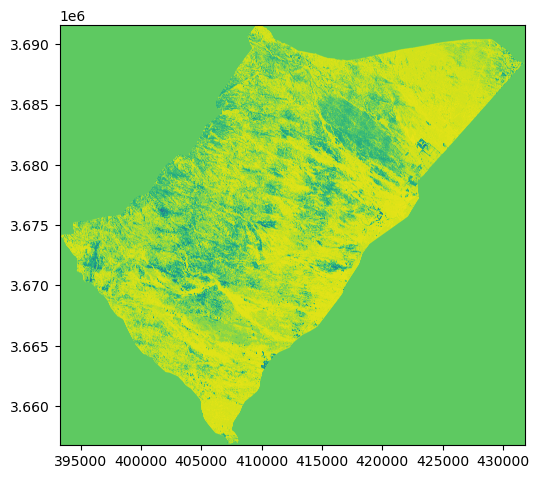

In [104]:
fig, ax = plt.subplots(figsize=(6,6))
show(predicted_raster, ax=ax, transform=src.transform)
plt.show()

In [103]:
profile.update(count=1) # Adjust dtype as needed
outfp = ra_dir + '20250711_PS_8b_pred.tif'
with rasterio.open(outfp, 'w', **profile) as dst:
    dst.write(predicted_raster, 1)

## Raster and Vector:MASKING AND REPROJECTION
- reference: https://automating-gis-processes.github.io/CSC/notebooks/L5/clipping-raster.html

In [16]:
ra_ref = rasterio.open(fp_ref)
ra_si = rasterio.open(fp_si)
ra_mo = rasterio.open(fp_mo)

In [18]:
print(ra_ref.meta) #epsg(32630)
print(ra_si.meta)
print(ra_mo.meta)

{'driver': 'GTiff', 'dtype': 'float32', 'nodata': nan, 'width': 12850, 'height': 11619, 'count': 8, 'crs': CRS.from_epsg(32630), 'transform': Affine(3.0, 0.0, 393249.0,
       0.0, -3.0, 3691608.0)}
{'driver': 'GTiff', 'dtype': 'float32', 'nodata': nan, 'width': 12850, 'height': 11619, 'count': 19, 'crs': CRS.from_epsg(32630), 'transform': Affine(3.0, 0.0, 393249.0,
       0.0, -3.0, 3691608.0)}
{'driver': 'GTiff', 'dtype': 'uint16', 'nodata': 0.0, 'width': 12850, 'height': 11619, 'count': 8, 'crs': CRS.from_epsg(32630), 'transform': Affine(3.0, 0.0, 393249.0,
       0.0, -3.0, 3691608.0)}


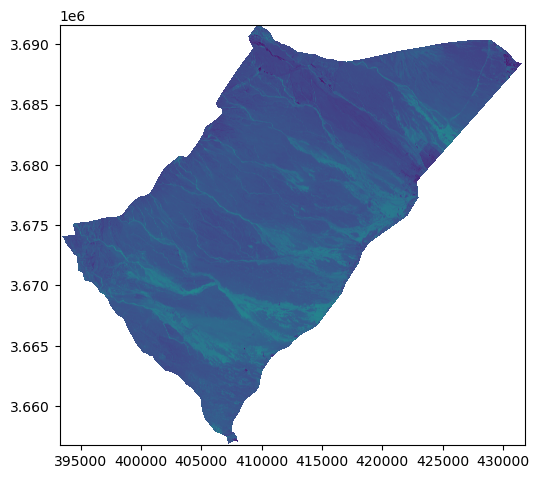

In [85]:
# Open PS raster dataset
with rasterio.open(fp_ref) as src:
    band_data = src.read(1)
    profile = src.profile
    fig, ax = plt.subplots(figsize=(6,6))
    show(band_data, ax=ax, transform=src.transform)
    plt.show()

EPSG:4326


<Axes: >

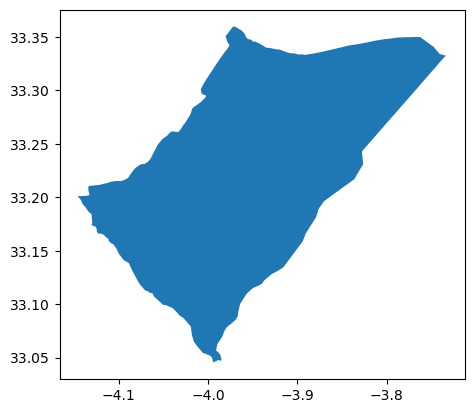

In [14]:
AI_shp.head()
print(AI_shp.crs) #EPSG:4326
AI_shp.plot()

In [19]:
AI_shp_prj = AI_shp.to_crs("EPSG:32630")

In [40]:
AI_shp_prj.crs

<Projected CRS: EPSG:32630>
Name: WGS 84 / UTM zone 30N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 6°W and 0°W, northern hemisphere between equator and 84°N, onshore and offshore. Algeria. Burkina Faso. Côte' Ivoire (Ivory Coast). Faroe Islands - offshore. France. Ghana. Gibraltar. Ireland - offshore Irish Sea. Mali. Mauritania. Morocco. Spain. United Kingdom (UK).
- bounds: (-6.0, 0.0, 0.0, 84.0)
Coordinate Operation:
- name: UTM zone 30N
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [27]:
def getFeatures(gdf):
    """Function to parse features from GeoDataFrame in such a manner that rasterio wants them"""
    import json
    return [json.loads(gdf.to_json())['features'][0]['geometry']]

In [20]:
# Define output path
shp_outfp = 'C:/Users/PangY/OneDrive - Smithsonian Institution/Bustard/01_Data/Reneco/GIS Data/Extract data Yuwen/Shapefiles/Al_Baten_study_area_prj.shp'

# Save file
AI_shp_prj.to_file(shp_outfp, driver='Shapefile')

In [44]:
AI_shape = getFeatures(AI_shp_prj)
# print(AI_shape)

In [22]:
ra_pred = rasterio.open(outfp)
ra_pred.meta

{'driver': 'GTiff',
 'dtype': 'float32',
 'nodata': nan,
 'width': 12850,
 'height': 11619,
 'count': 1,
 'crs': CRS.from_epsg(32630),
 'transform': Affine(3.0, 0.0, 393249.0,
        0.0, -3.0, 3691608.0)}

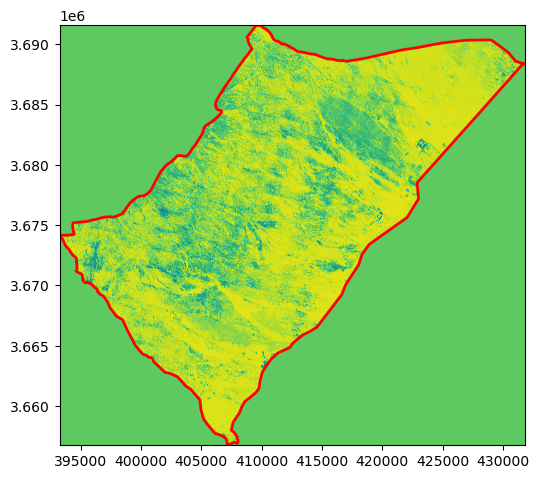

In [25]:
fig, ax = plt.subplots(figsize=(6,6))
show(ra_pred, ax=ax, transform=ra_pred.transform)
AI_shp_prj.plot(ax=ax, edgecolor='red', facecolor='none', linewidth=2)
plt.show()

In [45]:
# Clip the raster with Polygon
from rasterio.mask import mask
out_ra, out_transform = mask(dataset=ra_pred, shapes=AI_shape, crop=True)

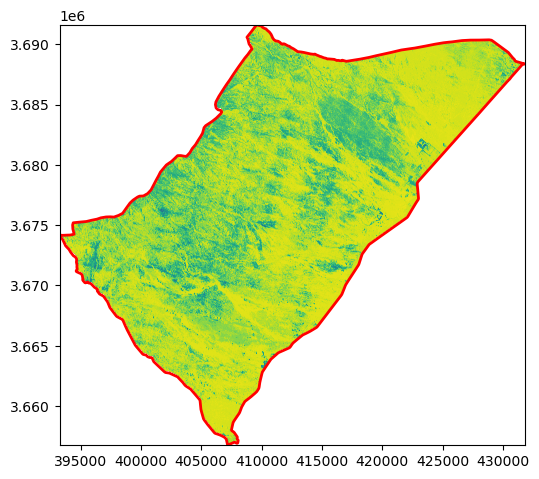

In [49]:
fig, ax = plt.subplots(figsize=(6,6))
show(out_ra, ax=ax, transform=ra_pred.transform)
AI_shp_prj.plot(ax=ax, edgecolor='red', facecolor='none', linewidth=2)
plt.show()

In [52]:
# Copy the metadata
out_meta = ra_pred.meta.copy()
print(out_meta)

out_meta.update({"driver": "GTiff",
                 "height": out_ra.shape[1],
                 "width": out_ra.shape[2],
                 "transform": out_transform})

print(f'the updated out meta',out_meta)

{'driver': 'GTiff', 'dtype': 'float32', 'nodata': nan, 'width': 12850, 'height': 11619, 'count': 1, 'crs': CRS.from_epsg(32630), 'transform': Affine(3.0, 0.0, 393249.0,
       0.0, -3.0, 3691608.0)}
the updated out meta {'driver': 'GTiff', 'dtype': 'float32', 'nodata': nan, 'width': 12850, 'height': 11619, 'count': 1, 'crs': CRS.from_epsg(32630), 'transform': Affine(3.0, 0.0, 393249.0,
       0.0, -3.0, 3691608.0)}


In [55]:
with rasterio.open(ra_dir + '20250711_PS_8b_pred_masked.tif', "w", **out_meta) as dest:
        dest.write(out_ra)

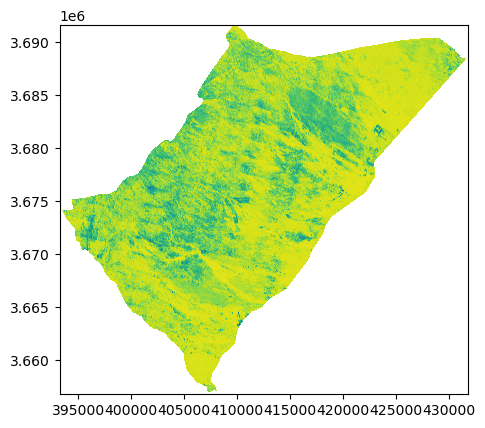

<Axes: >

In [58]:
# Open the clipped raster file
masked = rasterio.open(ra_dir + '20250711_PS_8b_pred_masked.tif')

# Visualize
show(masked, cmap='viridis')

## Post-process
- Raster mathamtics

In [9]:
masked = rasterio.open(ra_dir + '20250711_PS_8b_pred_masked.tif')
masked.meta

{'driver': 'GTiff',
 'dtype': 'float32',
 'nodata': nan,
 'width': 12850,
 'height': 11619,
 'count': 1,
 'crs': CRS.from_epsg(32630),
 'transform': Affine(3.0, 0.0, 393249.0,
        0.0, -3.0, 3691608.0)}

In [11]:
masked.shape[1]

12850

In [6]:
Fveg = 1- masked.read(1)
Fveg

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], dtype=float32)

In [14]:
Fveg.shape[0]

11619

In [12]:
Fveg_ra = Fveg.reshape(masked.shape[0], masked.shape[1])

In [18]:
# Copy the metadata
out_meta = masked.meta.copy()
with rasterio.open(ra_dir + '20250711_PS_8b_pred_masked_Fveg.tif', "w", **out_meta) as dest:
        dest.write(Fveg_ra, indexes=1)

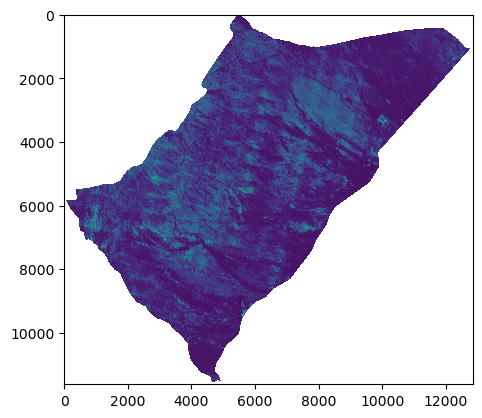

<Axes: >

In [19]:
# Visualize
show(Fveg, cmap='viridis')

## Land coer products
- ESA_WorldCover_10m: https://worldcover2020.esa.int/
https://worldcover2020.esa.int/downloader
- S2 Land cover product_10m: https://www.arcgis.com/home/item.html?id=cfcb7609de5f478eb7666240902d4d3d

In [21]:
lc_dir = 'C:/Users/PangY/OneDrive - Smithsonian Institution/Bustard/01_Data/S2-Land cover product/'
S2_fp = lc_dir + '30S_20240101-20241231.tif'
ESA_fp = lc_dir + 'WORLDCOVER/ESA_WorldCover_10m_2021_v200_N33W006_Map.tif'

EPSG:4326


<Axes: >

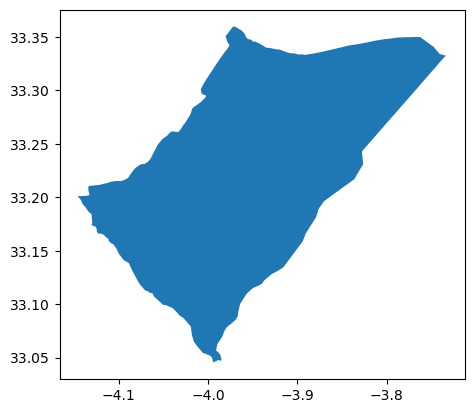

In [24]:
shp_fp = 'C:/Users/PangY/OneDrive - Smithsonian Institution/Bustard/01_Data/Reneco/GIS Data/Extract data Yuwen/Shapefiles/Al_Baten_study_area.shp'
AI_shp = gpd.read_file(shp_fp)
print(AI_shp.crs) #EPSG:4326
AI_shp.plot()

In [25]:
# Define output path
shp_prj = 'C:/Users/PangY/OneDrive - Smithsonian Institution/Bustard/01_Data/Reneco/GIS Data/Extract data Yuwen/Shapefiles/Al_Baten_study_area_prj.shp'
AI_shp_prj = gpd.read_file(shp_prj)
print(AI_shp_prj.crs) #EPSG:32630

EPSG:32630


In [28]:
AI_shape = getFeatures(AI_shp) #EPSG:4326
AI_prj_shape = getFeatures(AI_shp_prj) #EPSG:32630

### load raster and mask

In [23]:
S2_ra = rasterio.open(S2_fp)
S2_ra.meta

{'driver': 'GTiff',
 'dtype': 'uint8',
 'nodata': 0.0,
 'width': 56684,
 'height': 89162,
 'count': 1,
 'crs': CRS.from_epsg(32630),
 'transform': Affine(10.0, 0.0, 216580.0,
        0.0, -10.0, 4432060.0)}

In [22]:
ESA_ra = rasterio.open(ESA_fp)
ESA_ra.meta

{'driver': 'GTiff',
 'dtype': 'uint8',
 'nodata': 0.0,
 'width': 36000,
 'height': 36000,
 'count': 1,
 'crs': CRS.from_epsg(4326),
 'transform': Affine(8.333333333333333e-05, 0.0, -6.0,
        0.0, -8.333333333333333e-05, 36.0)}

In [29]:
# Clip the raster with Polygon
from rasterio.mask import mask
out_s2, out_transform1 = mask(dataset=S2_ra, shapes=AI_prj_shape, crop=True)
out_esa, out_transform2 = mask(dataset=ESA_ra, shapes=AI_shape, crop=True)

In [31]:
# Copy the metadata
out_meta1 = S2_ra.meta.copy()
print(out_meta1)
out_meta1.update({"driver": "GTiff",
                 "height": out_s2.shape[1],
                 "width": out_s2.shape[2],
                 "transform": out_transform1})

print(f'the updated out meta',out_meta1)
with rasterio.open(lc_dir + 'S2 Land cover_AI Baten.tif', "w", **out_meta1) as dest:
        dest.write(out_s2)

{'driver': 'GTiff', 'dtype': 'uint8', 'nodata': 0.0, 'width': 56684, 'height': 89162, 'count': 1, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.0, 0.0, 216580.0,
       0.0, -10.0, 4432060.0)}
the updated out meta {'driver': 'GTiff', 'dtype': 'uint8', 'nodata': 0.0, 'width': 3855, 'height': 3486, 'count': 1, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.0, 0.0, 393250.0,
       0.0, -10.0, 3691610.0)}


In [35]:
# Copy the metadata
out_meta2 = ESA_ra.meta.copy()
print(out_meta2)
out_meta2.update({"driver": "GTiff",
                 "height": out_esa.shape[1],
                 "width": out_esa.shape[2],
                 "transform": out_transform2})

print(f'the updated out meta',out_meta2)
with rasterio.open(lc_dir + 'WORLDCOVER/ESA_WorldCover_AI Baten.tif', "w", **out_meta2) as dest:
        dest.write(out_esa)

{'driver': 'GTiff', 'dtype': 'uint8', 'nodata': 0.0, 'width': 36000, 'height': 36000, 'count': 1, 'crs': CRS.from_epsg(4326), 'transform': Affine(8.333333333333333e-05, 0.0, -6.0,
       0.0, -8.333333333333333e-05, 36.0)}
the updated out meta {'driver': 'GTiff', 'dtype': 'uint8', 'nodata': 0.0, 'width': 4950, 'height': 3775, 'count': 1, 'crs': CRS.from_epsg(4326), 'transform': Affine(8.333333333333333e-05, 0.0, -4.145333333333333,
       0.0, -8.333333333333333e-05, 33.35991666666666)}


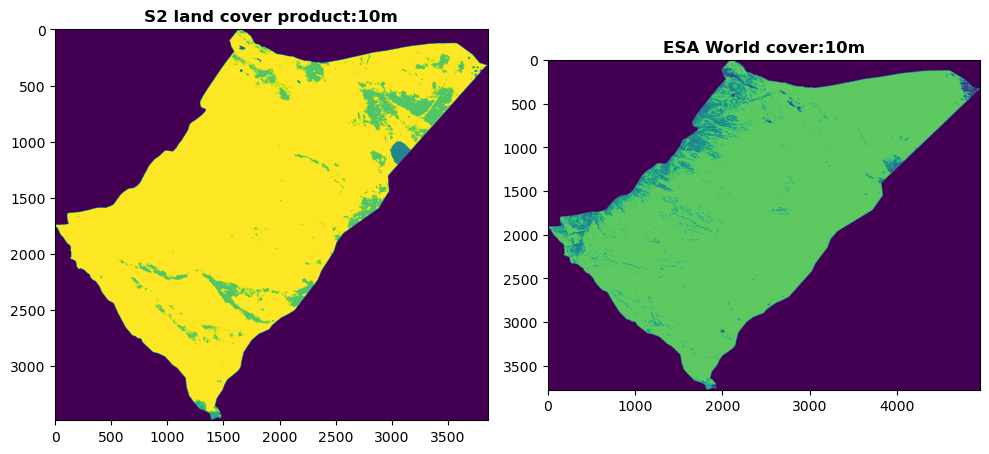

In [30]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
show((out_s2), ax=ax1, title="S2 land cover product:10m", cmap="viridis")
show((out_esa), ax=ax2, title="ESA World cover:10m", cmap="viridis")
plt.tight_layout()
plt.show()